# 04 — Programación Lineal

**Curso:** Inteligencia Artificial — Optimización (Clase 3)

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.
Los dos ejemplos son exactamente los que se formalizan en las slides de la
Clase 3, para que la transición slide → notebook no introduzca un problema
nuevo que el estudiante no haya visto formulado antes.

## Objetivos

- formular variables de decisión, función objetivo y restricciones;
- visualizar la región factible de un problema con dos variables;
- resolver un problema mediante enumeración de vértices y `scipy.optimize.linprog`;
- interpretar holguras y restricciones activas;
- convertir una restricción `≥` a la forma estándar `≤` que esperan los solvers.

![Descripción](https://drive.google.com/uc?export=view&id=1lNBEfy3ZR_bHsx-LJz1L7gip_C9ZEKSb)

## 1. Problema de producción: sillas y mesas

Una fábrica produce **sillas** ($x_1$) y **mesas** ($x_2$). Cada silla deja
\$25 de ganancia y cada mesa \$30.

| Recurso | Silla ($x_1$) | Mesa ($x_2$) | Disponible |
|---|---:|---:|---:|
| Madera | 2 unidades | 3 unidades | 120 unidades |
| Mano de obra | 1 h | 1 h | 50 h |

Modelo:

$$
\max 25x_1+30x_2
$$

sujeto a

$$
2x_1+3x_2\leq120
$$

$$
x_1+x_2\leq50
$$

$$
x_1,x_2\geq0
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

## 2. Visualización de la región factible

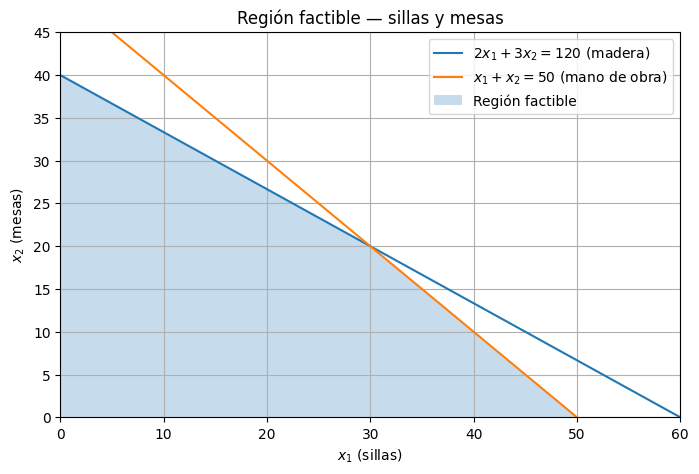

In [ ]:
x1 = np.linspace(0, 60, 500)
constraint_1 = (120 - 2 * x1) / 3
constraint_2 = 50 - x1
upper = np.minimum(constraint_1, constraint_2)
upper = np.maximum(upper, 0)

plt.figure(figsize=(8, 5))
plt.plot(x1, constraint_1, label=r'$2x_1+3x_2=120$ (madera)')
plt.plot(x1, constraint_2, label=r'$x_1+x_2=50$ (mano de obra)')
plt.fill_between(x1, 0, upper, where=(upper >= 0), alpha=0.25, label='Región factible')
plt.xlim(0, 60)
plt.ylim(0, 45)
plt.xlabel(r'$x_1$ (sillas)')
plt.ylabel(r'$x_2$ (mesas)')
plt.title('Región factible — sillas y mesas')
plt.legend()
plt.grid(True)
plt.show()

## 3. Solución mediante vértices

En un problema lineal con una región factible acotada, si existe un óptimo, al menos un vértice es óptimo. Para dos variables podemos calcularlos explícitamente.

In [ ]:
# Intersección entre las dos restricciones.
A = np.array([[2, 3], [1, 1]], dtype=float)
b = np.array([120, 50], dtype=float)
intersection = np.linalg.solve(A, b)

vertices = [
    np.array([0.0, 0.0]),
    np.array([50.0, 0.0]),   # x1 = 50 satura mano de obra antes que madera (120/2=60 > 50)
    np.array([0.0, 40.0]),   # x2 = 40 satura madera antes que mano de obra (120/3=40 < 50)
    intersection
]


def profit(x):
    return 25 * x[0] + 30 * x[1]

for vertex in vertices:
    print(f'x={vertex}, utilidad={profit(vertex):.2f}')

best_vertex = max(vertices, key=profit)
print()
print('Mejor vértice:', best_vertex)
print('Utilidad máxima:', profit(best_vertex))

x=[0. 0.], utilidad=0.00
x=[50.  0.], utilidad=1250.00
x=[ 0. 40.], utilidad=1200.00
x=[30. 20.], utilidad=1350.00

Mejor vértice: [30. 20.]
Utilidad máxima: 1350.0


Nota: con la utilidad original del ejemplo (\$20 por silla en vez de \$25),
el gradiente de la función objetivo queda exactamente paralelo a la
restricción de madera y hay **empate** entre dos vértices (óptimos
múltiples a lo largo de una arista). Con \$25 el óptimo es único — vale la
pena mencionar en clase que ese empate *sí* puede pasar en LP y no es un
error, es una propiedad real cuando el gradiente de la función objetivo
coincide en dirección con una restricción activa.

## 4. Solución con SciPy

`linprog` minimiza. Para maximizar $c^Tx$, minimizamos $-c^Tx$.

In [ ]:
c = np.array([-25, -30])
A_ub = np.array([[2, 3], [1, 1]])
b_ub = np.array([120, 50])
bounds = [(0, None), (0, None)]

result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

if not result.success:
    raise RuntimeError(result.message)

print('Solución:', result.x)
print('Utilidad máxima:', -result.fun)
print('Holguras:', result.ineqlin.residual)

Solución: [30. 20.]
Utilidad máxima: 1350.0
Holguras: [0. 0.]


Una holgura igual a cero indica que la restricción está **activa** en la solución. En este problema, ambos recursos se usan completamente.

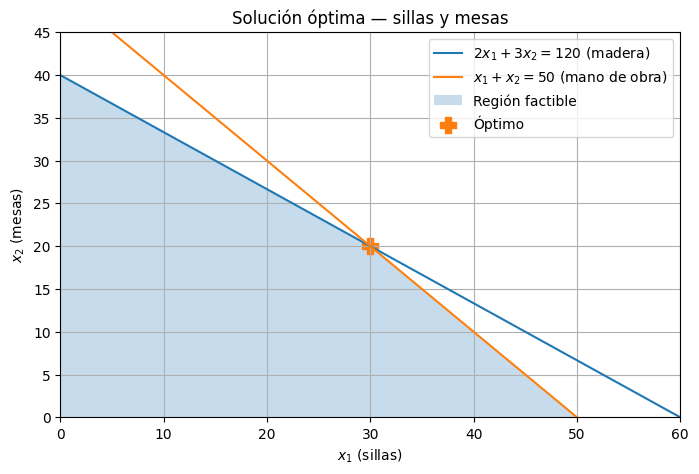

In [ ]:
solution = result.x

plt.figure(figsize=(8, 5))
plt.plot(x1, constraint_1, label=r'$2x_1+3x_2=120$ (madera)')
plt.plot(x1, constraint_2, label=r'$x_1+x_2=50$ (mano de obra)')
plt.fill_between(x1, 0, upper, where=(upper >= 0), alpha=0.25, label='Región factible')
plt.scatter([solution[0]], [solution[1]], s=130, marker='P', label='Óptimo')
plt.xlim(0, 60)
plt.ylim(0, 45)
plt.xlabel(r'$x_1$ (sillas)')
plt.ylabel(r'$x_2$ (mesas)')
plt.title('Solución óptima — sillas y mesas')
plt.legend()
plt.grid(True)
plt.show()

## 5. Análisis de sensibilidad básico

Modificaremos la utilidad de la mesa y observaremos cuándo cambia la solución óptima.

In [ ]:
profits_b = np.arange(10, 101, 5)
solutions = []

for p_b in profits_b:
    r = linprog([-25, -p_b], A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    solutions.append((p_b, r.x[0], r.x[1], -r.fun))

print('utilidad_mesa | x1 (sillas) | x2 (mesas) | utilidad total')
for p_b, x_1, x_2, value in solutions:
    print(f'{p_b:>13.0f} | {x_1:>11.1f} | {x_2:>10.1f} | {value:>14.1f}')

utilidad_mesa | x1 (sillas) | x2 (mesas) | utilidad total
           10 |        50.0 |        0.0 |         1250.0
           15 |        50.0 |        0.0 |         1250.0
           20 |        50.0 |        0.0 |         1250.0
           25 |        30.0 |       20.0 |         1250.0
           30 |        30.0 |       20.0 |         1350.0
           35 |        30.0 |       20.0 |         1450.0
           40 |         0.0 |       40.0 |         1600.0
           45 |         0.0 |       40.0 |         1800.0
           50 |         0.0 |       40.0 |         2000.0
           55 |         0.0 |       40.0 |         2200.0
           60 |         0.0 |       40.0 |         2400.0
           65 |         0.0 |       40.0 |         2600.0
           70 |         0.0 |       40.0 |         2800.0
           75 |         0.0 |       40.0 |         3000.0
           80 |         0.0 |       40.0 |         3200.0
           85 |         0.0 |       40.0 |         3400.0
           90 

## 6. Segundo ejemplo: dos máquinas (minimización)

Una variante útil porque **minimiza** en vez de maximizar, y porque obliga
a convertir una restricción `≥` a la forma estándar `≤` que espera
`linprog`. Este es el mismo ejemplo que aparece formulado en la slide de
la Clase 3.

- Dos máquinas $x_1, x_2$ (horas de uso). $x_1$ cuesta \$50/hora, $x_2$
  cuesta \$80/hora. **Minimizar**: $50x_1+80x_2$.
- Mano de obra disponible: $x_1$ requiere 5 unidades/hora, $x_2$ requiere
  2 unidades/hora, con 20 unidades totales disponibles:
  $5x_1+2x_2\leq20$.
- Producción mínima requerida: $x_1$ produce 10 unidades/hora, $x_2$
  produce 12 unidades/hora, y se necesitan al menos 90 unidades:
  $10x_1+12x_2\geq90$.

`linprog` solo acepta restricciones en la forma $\leq$, así que
multiplicamos la segunda restricción por $-1$:
$-10x_1-12x_2\leq-90$.

In [ ]:
c_machines = [50, 80]
A_ub_machines = [[5, 2], [-10, -12]]
b_ub_machines = [20, -90]

result_machines = linprog(
    c_machines,
    A_ub=A_ub_machines,
    b_ub=b_ub_machines,
    bounds=[(0, None), (0, None)],
    method='highs'
)

if result_machines.success:
    print(f"X1: {round(result_machines.x[0], 2)} horas")
    print(f"X2: {round(result_machines.x[1], 2)} horas")
    print(f"Costo mínimo: {round(result_machines.fun, 2)}")
else:
    print("No solution")

X1: 1.5 horas
X2: 6.25 horas
Costo mínimo: 575.0


## Actividades

### Actividad 1 — Restricción adicional

Agrega una restricción de almacenamiento al problema de sillas y mesas:

$$
4x_1+2x_2\leq160
$$

Grafica la nueva región factible y resuelve el modelo.

In [ ]:
# TODO: agrega la tercera restricción.
A_ub_extended = None
b_ub_extended = None

# result_extended = linprog(...)

### Actividad 2 — Producción mínima

El contrato exige producir al menos 10 mesas:

$$
x_2\geq10
$$

Representa esta condición correctamente en `linprog` y resuelve el problema de sillas y mesas.

### Actividad 3 — Inviabilidad

Crea una restricción adicional que vuelva el problema de sillas y mesas inviable. Comprueba el estado retornado por SciPy y explica qué significa.

### Actividad 4 — Variables enteras

¿Tiene sentido producir 37.5 sillas? Investiga la diferencia conceptual entre programación lineal y programación lineal entera. No es necesario implementar un solver entero en este notebook.

### Actividad 5 — El empate de la Sección 3

Vuelve a correr la Sección 3 con la utilidad original de \$20 por silla en
vez de \$25. Verifica que (0,40) y (30,20) empatan, y explica en tus
palabras por qué el problema de las dos máquinas de la Sección 6 no
tiene ese mismo riesgo (piensa en la relación entre el gradiente de la
función objetivo y las normales de las restricciones activas).

## Preguntas de cierre

1. ¿Qué diferencia hay entre una restricción y la función objetivo?
2. ¿Qué significa que una solución sea factible?
3. ¿Por qué `linprog` recibe el negativo de las utilidades al maximizar?
4. ¿Toda solución óptima usa por completo todos los recursos?
5. ¿Puede un problema de LP tener más de una solución óptima? ¿Bajo qué condición geométrica ocurre?